<a href="https://colab.research.google.com/github/kosar-am/finance-prediction-rnn/blob/main/notebooks/01_data_collection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google Stock Price Prediction using RNN, LSTM, and GRU

## 01 — Data Collection

In this notebook, historical stock market data for Google will be collected and saved for later preprocessing and modeling.

### Objectives
- Download historical Google stock data
- Inspect the dataset
- Check the date range and available features
- Save the raw dataset in the `data/raw/` directory

## 📚 Import Required Libraries



In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

## 📥 Download Dataset

In this section, we download the historical stock price data for Google using the Yahoo Finance API.

### Dataset Information
- **Company:** Google (Alphabet Inc.)
- **Ticker Symbol:** GOOG
- **Source:** Yahoo Finance
- **Period:** 2015 - Present
- **Frequency:** Daily

In [2]:
# Download Google stock data
df = yf.download(
    "GOOG",
    start="2015-01-01",
    end="2025-12-31",
    auto_adjust=True
)



[*********************100%***********************]  1 of 1 completed


## 🛠️ Clean Column Names


In [3]:
# Convert MultiIndex columns to a single level
df.columns = df.columns.get_level_values(0)

# Display the first five rows after cleaning the column names
df.head(10)

Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,25.939947,26.259249,25.904854,26.147542,28951268
2015-01-05,25.399218,25.916228,25.359182,25.863340,41196796
2015-01-06,24.810537,25.513148,24.765560,25.455070,57998800
2015-01-07,24.768030,25.071711,24.696360,25.059650,41301082
2015-01-08,24.846123,24.885664,24.268811,24.614308,67071641
2015-01-09,24.524353,24.956840,24.456143,24.948933,41427428
2015-01-12,24.345421,24.514759,24.098778,24.463552,46535413
2015-01-13,24.524845,24.860949,24.337515,24.656321,47409807
2015-01-14,24.756660,24.873308,24.367666,24.449223,44714427


In [4]:
# Display the column names
print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


## Remove Column Index Name

After flattening the MultiIndex columns, Pandas still keeps the column index name (`Price`).

Removing this label makes the dataset cleaner and improves readability.

In [5]:
# Remove the column index name
df.columns.name = None

# Display the first ten rows
df.head(10)

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,25.939947,26.259249,25.904854,26.147542,28951268
2015-01-05,25.399218,25.916228,25.359182,25.863340,41196796
2015-01-06,24.810537,25.513148,24.765560,25.455070,57998800
2015-01-07,24.768030,25.071711,24.696360,25.059650,41301082
2015-01-08,24.846123,24.885664,24.268811,24.614308,67071641
2015-01-09,24.524353,24.956840,24.456143,24.948933,41427428
2015-01-12,24.345421,24.514759,24.098778,24.463552,46535413
2015-01-13,24.524845,24.860949,24.337515,24.656321,47409807
2015-01-14,24.756660,24.873308,24.367666,24.449223,44714427


## 📏 Check Dataset Shape



In [6]:
# Display the number of rows and columns in the dataset
df.shape

(2765, 5)

## ℹ️ Display Dataset Information

In [7]:
# Display general information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2765 entries, 2015-01-02 to 2025-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2765 non-null   float64
 1   High    2765 non-null   float64
 2   Low     2765 non-null   float64
 3   Open    2765 non-null   float64
 4   Volume  2765 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 129.6 KB


## 📊 Summary Statistics

In [8]:
# Display summary statistics of the numerical columns
df.describe()

,Close,High,Low,Open,Volume
count,2765.000000,2765.000000,2765.000000,2765.000000,2.765000e+03
mean,93.700369,94.679474,92.676974,93.642081,3.012919e+07
std,58.062993,58.734501,57.367849,58.040328,1.512357e+07
min,24.345421,24.514759,24.098778,24.449223,6.138200e+06
25%,48.204998,48.535581,47.829802,48.186154,2.078600e+07
50%,73.036552,73.688313,72.302771,72.822936,2.645290e+07
75%,134.512527,135.753117,132.789245,134.315752,3.490780e+07
max,323.006897,328.027056,319.354042,326.160688,2.232980e+08


## 🔍 Check Missing Values

In [9]:
# Check the number of missing values in each column
df.isnull().sum()

,0
Close,0
High,0
Low,0
Open,0
Volume,0


## 📈 Closing Price Over Time

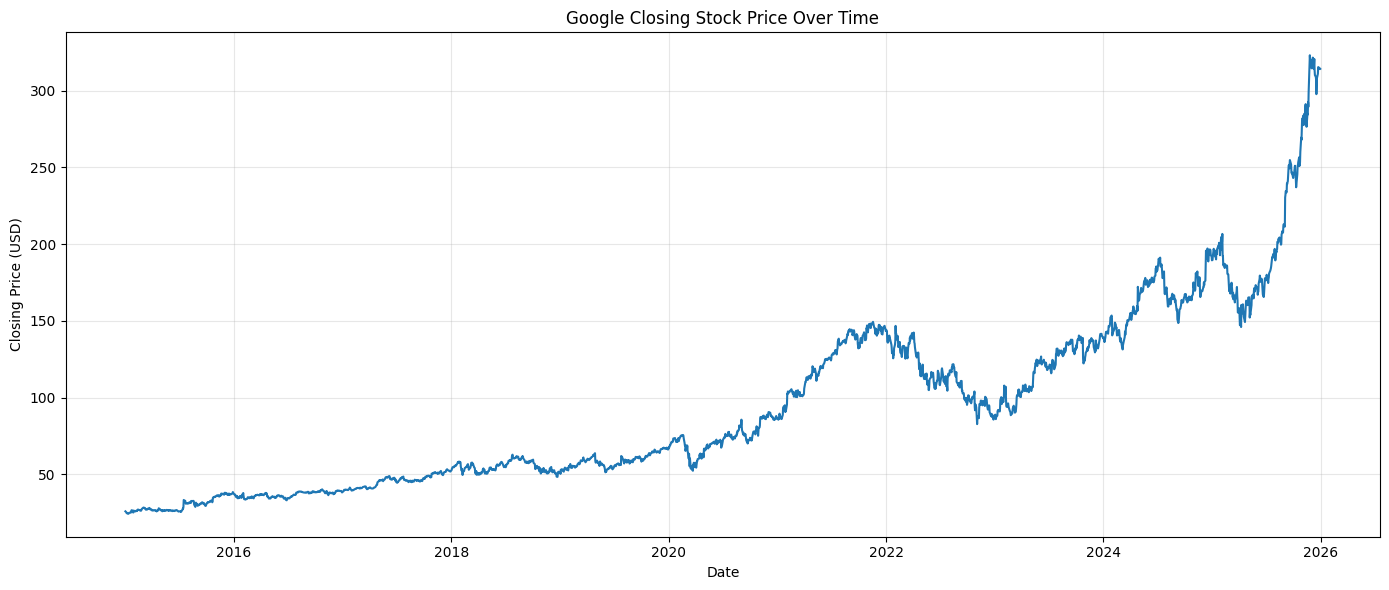

In [10]:
# Create a figure for the closing price chart
plt.figure(figsize=(14, 6))

# Plot Google's closing stock price over time
plt.plot(df.index, df["Close"])

# Add a descriptive title and axis labels
plt.title("Google Closing Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")

# Add a grid to improve chart readability
plt.grid(True, alpha=0.3)

# Adjust the layout and display the chart
plt.tight_layout()
plt.show()

### 📌 Observation

- The closing price follows a clear long-term upward trend.
- Several short-term corrections are visible throughout the period.
- The stock experiences accelerated growth during the final months of the dataset.

### 💡 Insight

The Google stock price exhibits a strong long-term growth pattern with short-term market fluctuations. Since the price level changes significantly over time, the series is non-stationary and will require normalization before training deep learning models.

## 📊 Trading Volume Over Time

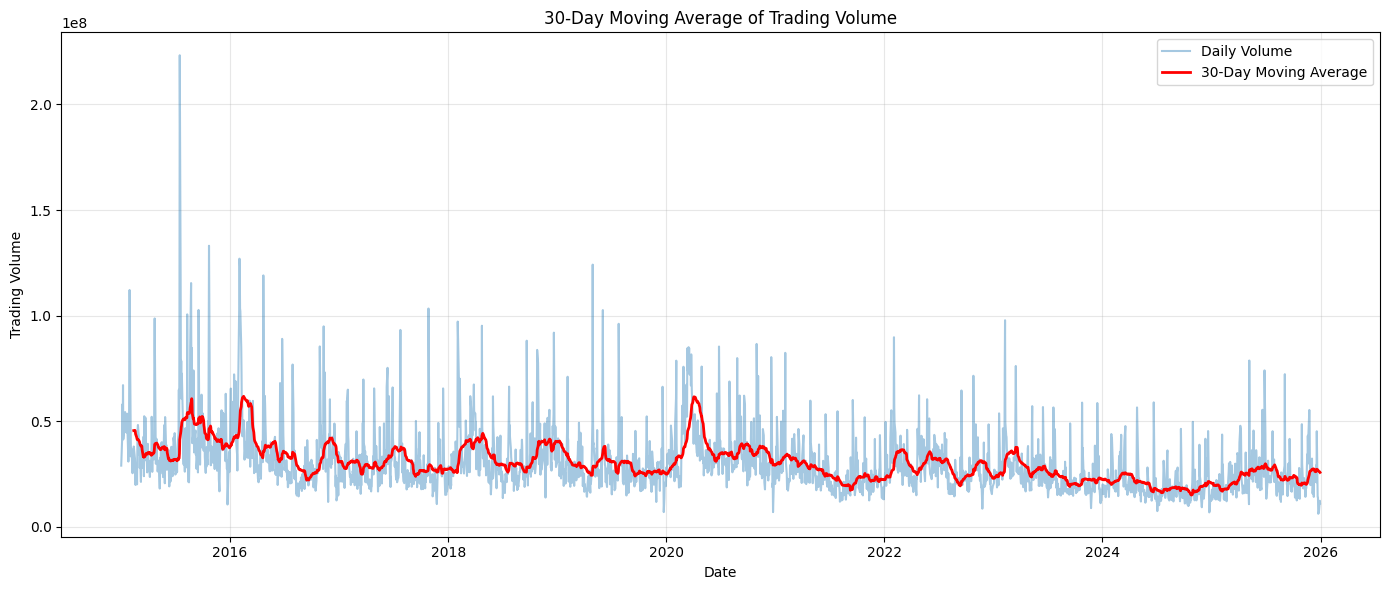

In [12]:
# Calculate the 30-day moving average of trading volume
volume_ma30 = df["Volume"].rolling(window=30).mean()

# Create a figure
plt.figure(figsize=(14, 6))

# Plot the original trading volume
plt.plot(
    df.index,
    df["Volume"],
    alpha=0.4,
    label="Daily Volume"
)

# Plot the 30-day moving average
plt.plot(
    df.index,
    volume_ma30,
    linewidth=2,
    color="red",
    label="30-Day Moving Average"
)

# Add a descriptive title and axis labels
plt.title("30-Day Moving Average of Trading Volume")
plt.xlabel("Date")
plt.ylabel("Trading Volume")

# Display the legend
plt.legend()

# Add a grid
plt.grid(True, alpha=0.3)

# Adjust layout and display the chart
plt.tight_layout()
plt.show()

### 📌 Observation

- Daily trading volume contains frequent short-term spikes.
- The 30-day moving average reveals a slight long-term decline in average trading volume.
- Temporary increases in market activity are visible during several periods, particularly around 2020.
- Trading volume remains highly volatile despite the overall downward tendency.

### 💡 Insight

The moving average confirms that average trading activity has gradually decreased over time, although the pattern is not strictly downward. The remaining volume spikes may reflect periods of unusual market attention or major company-related events.

## 📈 Closing Price with Moving Averages

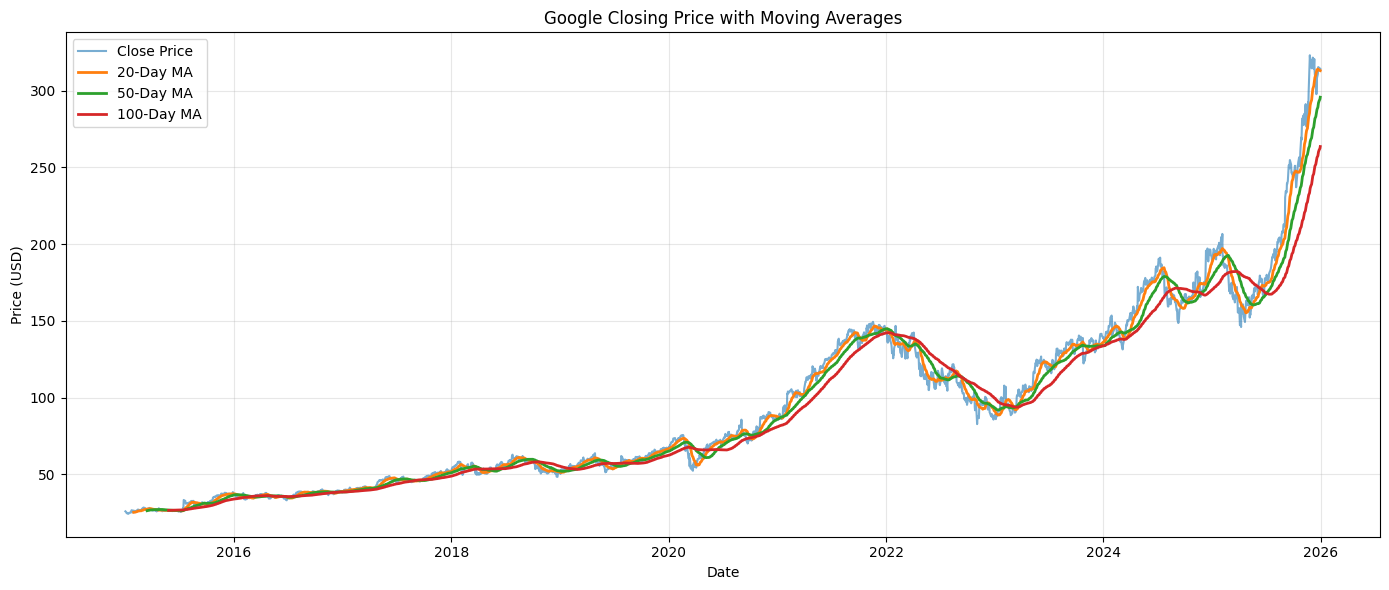

In [13]:
# Calculate moving averages
df["MA20"] = df["Close"].rolling(window=20).mean()
df["MA50"] = df["Close"].rolling(window=50).mean()
df["MA100"] = df["Close"].rolling(window=100).mean()

# Create a figure
plt.figure(figsize=(14, 6))

# Plot closing price
plt.plot(df.index, df["Close"], label="Close Price", alpha=0.6)

# Plot moving averages
plt.plot(df.index, df["MA20"], label="20-Day MA", linewidth=2)
plt.plot(df.index, df["MA50"], label="50-Day MA", linewidth=2)
plt.plot(df.index, df["MA100"], label="100-Day MA", linewidth=2)

# Add title and labels
plt.title("Google Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

# Display legend
plt.legend()

# Add grid
plt.grid(True, alpha=0.3)

# Adjust layout and display the chart
plt.tight_layout()
plt.show()

### 📌 Observation

- The closing price closely follows the moving averages throughout the period.
- The 20-day moving average reacts quickly to short-term price changes.
- The 50-day moving average captures the medium-term trend with smoother movements.
- The 100-day moving average provides a clear representation of the long-term trend.
- All moving averages indicate a strong upward trend during the final stage of the dataset.



### 💡 Insight

Moving averages smooth out daily price fluctuations and make the underlying trend easier to identify. Shorter moving averages respond more quickly to market changes, while longer moving averages provide a more stable view of the long-term trend. These indicators are widely used in financial analysis to identify trend direction and potential trading signals.

## 📉 Daily Returns

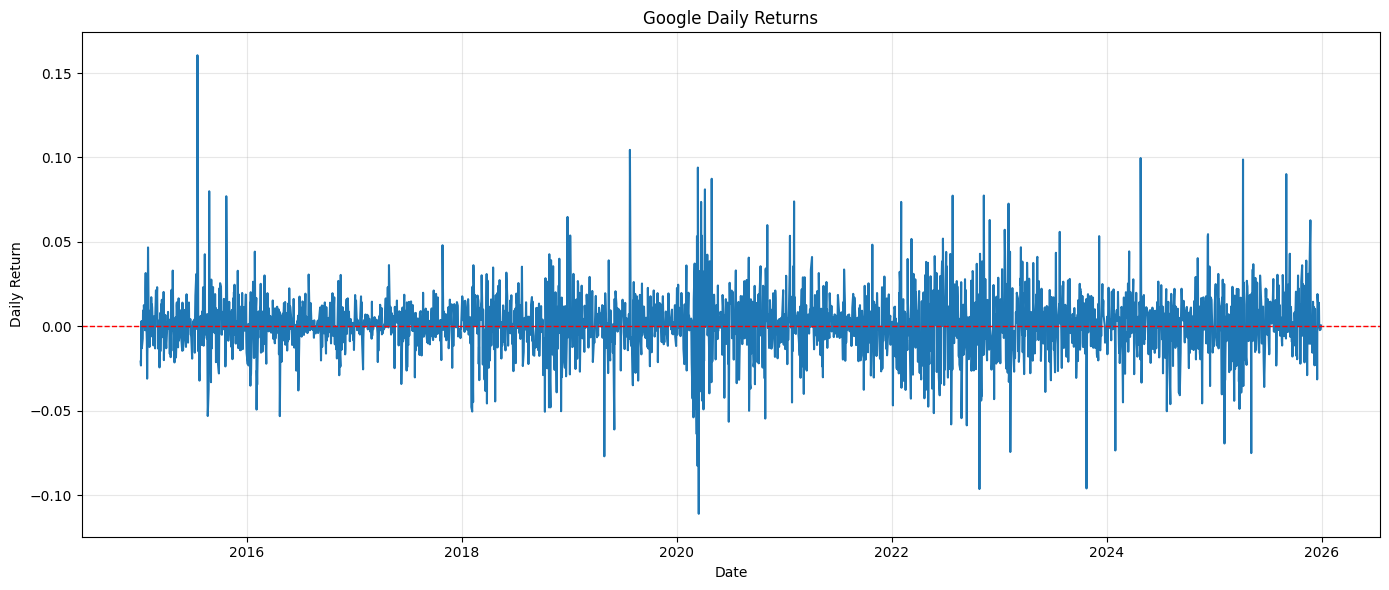

In [14]:
# Calculate the daily percentage return
df["Daily Return"] = df["Close"].pct_change()

# Create a figure
plt.figure(figsize=(14, 6))

# Plot daily returns
plt.plot(df.index, df["Daily Return"])

# Add title and axis labels
plt.title("Google Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

# Add a horizontal reference line at zero
plt.axhline(y=0, color="red", linestyle="--", linewidth=1)

# Add a grid
plt.grid(True, alpha=0.3)

# Adjust layout and display the chart
plt.tight_layout()
plt.show()

### 📌 Observation

- Daily returns fluctuate around zero throughout the entire period.
- Both positive and negative return spikes are observed.
- Several periods exhibit higher volatility with larger price swings.
- Most daily returns remain within a relatively narrow range around zero.

### 💡 Insight

Unlike stock prices, daily returns do not show a long-term upward trend and instead oscillate around zero. This behavior provides a clearer view of market volatility and highlights periods of increased risk. Large positive or negative spikes indicate days with unusually strong market movements.

## 📊 Distribution of Daily Returns

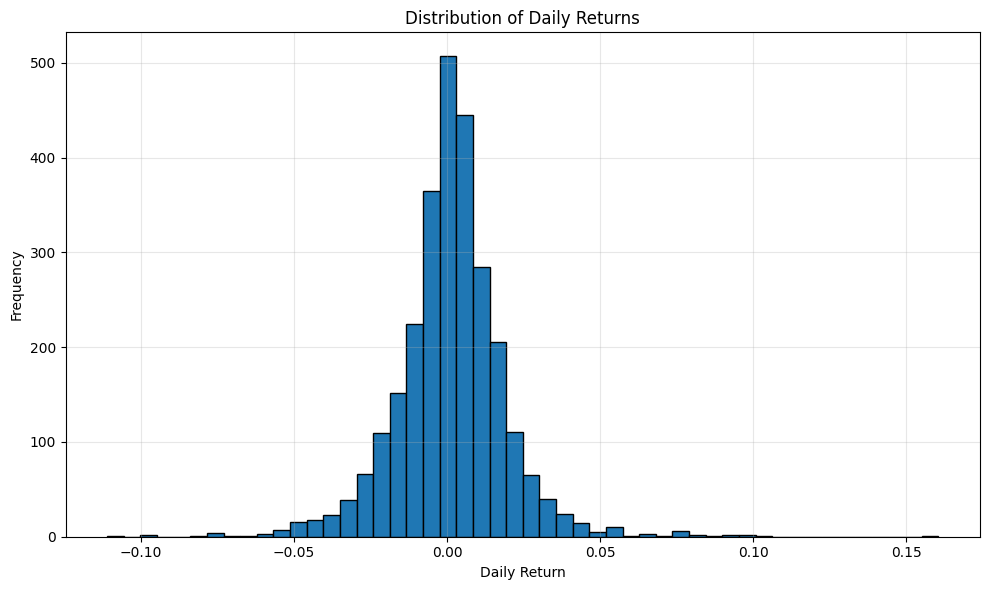

In [15]:
# Create a figure
plt.figure(figsize=(10, 6))

# Plot the distribution of daily returns
plt.hist(
    df["Daily Return"].dropna(),
    bins=50,
    edgecolor="black"
)

# Add title and axis labels
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

# Add a grid
plt.grid(True, alpha=0.3)

# Adjust layout and display the chart
plt.tight_layout()
plt.show()

### 📌 Observation

- Most daily returns are concentrated around zero.
- The distribution is approximately bell-shaped.
- Both positive and negative extreme returns are present.
- The distribution has long tails, indicating occasional large price movements.


### 💡 Insight

The histogram shows that most trading days experience relatively small price changes, while large gains and losses occur less frequently. The presence of long tails suggests that extreme market movements can occur, which is a common characteristic of financial time series.

## 📦 Boxplot of Daily Returns

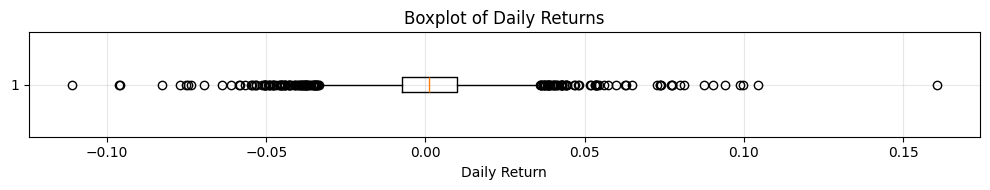

In [16]:
# Create a figure
plt.figure(figsize=(10, 2))

# Plot the boxplot of daily returns
plt.boxplot(
    df["Daily Return"].dropna(),
    vert=False
)

# Add title and axis label
plt.title("Boxplot of Daily Returns")
plt.xlabel("Daily Return")

# Add a grid
plt.grid(True, alpha=0.3)

# Adjust layout and display the chart
plt.tight_layout()
plt.show()

### 📌 Observation

- The median daily return is close to zero.
- Most daily returns are concentrated within a narrow range.
- Numerous outliers are present on both the positive and negative sides.
- Positive and negative extreme returns indicate occasional large market movements.

### 💡 Insight

The boxplot confirms that daily returns contain many outliers, which is common in financial markets. While most trading days experience relatively small price changes, extreme positive and negative returns occur occasionally, reflecting periods of unusually high market volatility.

## 🔥 Correlation Heatmap

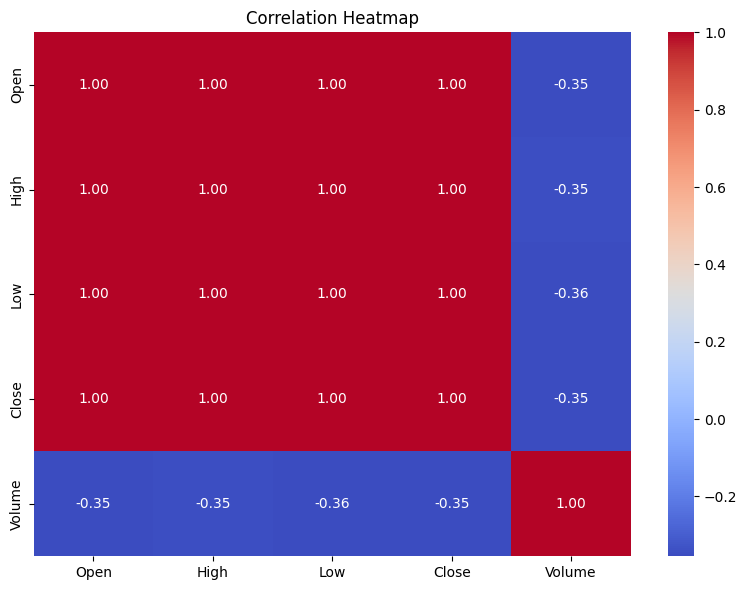

In [17]:
# Import seaborn
import seaborn as sns

# Create a figure
plt.figure(figsize=(8, 6))

# Compute the correlation matrix
correlation = df[["Open", "High", "Low", "Close", "Volume"]].corr()

# Plot the heatmap
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

# Add title
plt.title("Correlation Heatmap")

# Display the chart
plt.tight_layout()
plt.show()

### 📌 Observation

- Open, High, Low, and Close prices are extremely highly correlated.
- Trading volume shows a moderate negative correlation with all price variables.
- The price-related features contain largely overlapping information.


### 💡 Insight

The strong correlations among Open, High, Low, and Close indicate substantial multicollinearity. Using all four variables may provide limited additional information compared with using the closing price alone. The negative relationship between volume and price should be interpreted cautiously, since correlation over a long, trending time series does not necessarily imply a direct causal relationship.

## 📊 Distribution of Closing Prices

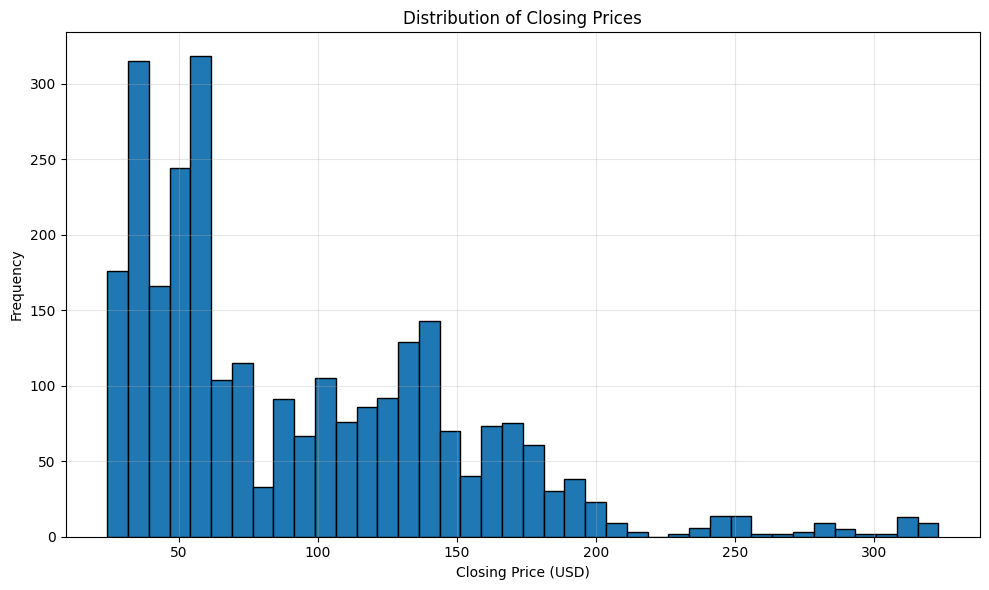

In [18]:
# Create a figure
plt.figure(figsize=(10, 6))

# Plot the distribution of closing prices
plt.hist(
    df["Close"],
    bins=40,
    edgecolor="black"
)

# Add title and labels
plt.title("Distribution of Closing Prices")
plt.xlabel("Closing Price (USD)")
plt.ylabel("Frequency")

# Add grid
plt.grid(True, alpha=0.3)

# Adjust layout and display the chart
plt.tight_layout()
plt.show()

### 📌 Observation

- The distribution of closing prices is right-skewed.
- Lower price ranges occur more frequently than higher price ranges.
- High closing prices appear less frequently and form a long right tail.
- The closing prices are not normally distributed.

### 💡 Insight

The histogram indicates that Google's stock traded at lower price levels for a larger portion of the observed period, while higher prices were reached mainly in recent years. The right-skewed distribution reflects the long-term upward trend of the stock price and further supports the need for feature scaling before training deep learning models.